# End-to-End Retail Analytics: Custom AutoML Pipeline (Optimized)
**Project:** Retail Sales Forecasting & Customer Churn Prediction  
**Author:** Antigravity (AI Agent)  
**Approach:** Custom Scikit-Learn Wrapper ("Mini-PyCaret")  

This notebook implements a robust, lightweight Data Science workflow using standard libraries (`scikit-learn`, `xgboost`, `imblearn`).

**Key Improvements:**
1.  **SMOTE (Synthetic Minority Over-sampling):** Handles unbalanced classes in Churn Prediction.
2.  **Optimized Workflow:** Separate cells for clear reporting.
3.  **Detailed Insights:** Feature Importance, Residuals, and Class-level metrics.

In [36]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time

# Scikit-Learn Ecosystem
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, classification_report

# Imbalanced Learn (SMOTE)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # Pipeline that supports SMOTE

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
import xgboost as xgb

print("Global Environment Ready (Scikit-Learn + XGBoost + SMOTE)")
print(f"Current QDir: {os.getcwd()}")

Global Environment Ready (Scikit-Learn + XGBoost + SMOTE)
Current QDir: h:\coding\Quantum_Virtual_Project


## 🛠️ Custom AutoML Functions (The "Mini-PyCaret")
Defining reusable functions to automate Training, Comparing, Tuning, and Interpreting.

In [37]:
def setup_data(df, target, task='regression'):
    """Simulates PyCaret's setup(): Splits data and prepares preprocessor."""
    X = df.drop(columns=[target, 'DATE'], errors='ignore')
    y = df[target]
    
    # Identify categorical & numerical columns
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    num_cols = X.select_dtypes(include=['number']).columns.tolist()
    
    # Preprocessing Pipeline
    numeric_transformer = ImbPipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    categorical_transformer = ImbPipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, num_cols),
            ('cat', categorical_transformer, cat_cols)
        ]
    )
    
    # Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y if task=='classification' else None)
    
    return X_train, X_test, y_train, y_test, preprocessor

In [38]:
def compare_models(X_train, y_train, preprocessor, task='regression', use_smote=False):
    """Compares multiple models using Simple Train/Validation Split (No CV loop)."""
    results = []
    trained_models = {}
    
    # Split Training data further into Train/Validation for Comparison
    X_t, X_v, y_t, y_v = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train if task=='classification' else None)
    
    if task == 'regression':
        models = {
            'Linear Regression': LinearRegression(),
            'Ridge': Ridge(),
            'Random Forest': RandomForestRegressor(n_jobs=-1, random_state=42),
            'XGBoost': xgb.XGBRegressor(n_jobs=-1, random_state=42)
        }
        metric_name = 'Val RMSE'
    else:
        models = {
            'Logistic Regression': LogisticRegression(max_iter=1000),
            'Random Forest': RandomForestClassifier(n_jobs=-1, random_state=42),
            'XGBoost': xgb.XGBClassifier(n_jobs=-1, random_state=42, eval_metric='logloss')
        }
        metric_name = 'Val Accuracy'
    
    print(f"Comparing Models for {task.upper()} (Validation Split)...")
    
    best_model_name = None
    best_score = float('-inf') if task == 'classification' else float('inf')
    
    for name, model in models.items():
        start = time.time()
        
        # Build Pipeline
        steps = [('preprocessor', preprocessor)]
        if use_smote and task == 'classification':
            steps.append(('smote', SMOTE(random_state=42)))
        steps.append(('classifier', model))
        
        clf = ImbPipeline(steps=steps)
        
        # Fit on Sub-Train, Score on Validation
        clf.fit(X_t, y_t)
        
        if task == 'regression':
            y_pred = clf.predict(X_v)
            score = np.sqrt(mean_squared_error(y_v, y_pred))
            # Minimal is better for RMSE
            is_better = score < best_score
        else:
            score = clf.score(X_v, y_v)
            # Maximal is better for Accuracy
            is_better = score > best_score
        
        trained_models[name] = model
        
        results.append({
            'Model': name,
            metric_name: score,
            'Time (s)': time.time() - start
        })
        
        if is_better:
            best_score = score
            best_model_name = name
            
    # Sort results
    results_df = pd.DataFrame(results).sort_values(by=metric_name, ascending=(task=='regression'))
    print(f"Best Model: {best_model_name}")
    display(results_df)
    
    return trained_models[best_model_name], best_model_name

In [39]:
def tune_model(model, model_name, X_train, y_train, preprocessor, task='regression', use_smote=False):
    """Performs Hyperparameter Tuning using GridSearchCV on the Best Model."""
    print(f"\n--- Tuning {model_name} ---")
    
    param_grids = {
        'Random Forest': {
            'classifier__n_estimators': [50, 100, 200],
            'classifier__max_depth': [None, 10, 20],
            'classifier__min_samples_split': [2, 5]
        },
        'XGBoost': {
            'classifier__n_estimators': [50, 100, 200],
            'classifier__learning_rate': [0.01, 0.1, 0.2],
            'classifier__max_depth': [3, 6, 10]
        },
        'Logistic Regression': {'classifier__C': [0.1, 1, 10]},
        'Ridge': {'classifier__alpha': [0.1, 1.0, 10.0]},
        'Lasso': {'classifier__alpha': [0.1, 1.0, 10.0]},
        'Linear Regression': {} 
    }

    steps = [('preprocessor', preprocessor)]
    if use_smote and task == 'classification':
        print("Applying SMOTE inside Cross-Validation...")
        steps.append(('smote', SMOTE(random_state=42)))
    steps.append(('classifier', model))

    pipeline = ImbPipeline(steps=steps)
    
    grid = param_grids.get(model_name, {})
    
    if not grid:
        print("No hyperparameter grid defined for this model. Returning default.")
        pipeline.fit(X_train, y_train)
        return pipeline

    scoring = 'neg_root_mean_squared_error' if task == 'regression' else 'accuracy'
    
    # Here we KEEP standard CV because Tuning relies on it
    search = GridSearchCV(pipeline, grid, cv=3, scoring=scoring, n_jobs=-1, verbose=1)
    search.fit(X_train, y_train)
    
    print(f"Best Parameters: {search.best_params_}")
    return search.best_estimator_

In [40]:
def evaluate_model(pipeline, X_test, y_test, task='regression'):
    """Plots Evaluation Metrics and Feature Importance (Insights) individually."""
    y_pred = pipeline.predict(X_test)
    model_step = pipeline.named_steps['classifier']
    
    print("--- Model Evaluation ---")
    
    if task == 'regression':
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        print(f"Test RMSE: {rmse:.4f}")
        print(f"Test R2: {r2:.4f}")
        
        # 1. Prediction Error Plot
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
        plt.xlabel('Actual Sales')
        plt.ylabel('Predicted Sales')
        plt.title('Prediction Error (Actual vs Predicted)')
        plt.show()
        
        # 2. Residuals Distribution
        plt.figure(figsize=(8, 6))
        sns.histplot(y_test - y_pred, kde=True)
        plt.xlabel('Error (Actual - Predicted)')
        plt.title('Residuals Distribution')
        plt.show()

    else:
        print("Classification Report:")
        print(classification_report(y_test, y_pred))
        print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
        print(f"AUC-ROC:  {roc_auc_score(y_test, y_pred):.4f}")
        
        # 1. Confusion Matrix
        plt.figure(figsize=(8, 6))
        sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
        plt.xlabel('Predicted Label')
        plt.ylabel('Actual Label')
        plt.title('Confusion Matrix')
        plt.show()
        
        # 2. ROC-AUC Curve
        plt.figure(figsize=(8, 6))
        if hasattr(model_step, 'predict_proba'):
            y_prob = pipeline.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_prob)
            auc = roc_auc_score(y_test, y_prob)
            plt.plot(fpr, tpr, label=f"AUC={auc:.2f}")
            plt.plot([0,1],[0,1],'k--')
            plt.legend()
            plt.title('ROC-AUC Curve')
            plt.show()
    
    # 3. INSIGHTS: Feature Importance
    plt.figure(figsize=(10, 6))
    try:
        if hasattr(model_step, 'feature_importances_'):
            importances = model_step.feature_importances_
            feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
            
            feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
            feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(10)
            
            sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis')
            plt.title('Top 10 Feature Importances')
            plt.show()
        elif hasattr(model_step, 'coef_'):
            feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
            importances = np.abs(model_step.coef_[0]) if len(model_step.coef_.shape)>1 else np.abs(model_step.coef_)
            
            feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
            feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(10)
            
            sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='magma')
            plt.title('Top 10 Feature Coefficients')
            plt.show()
    except Exception as e:
        print(f"Could not plot features: {e}")

In [41]:
def save_pipeline_custom(pipeline, filename):
    """Saves the entire pipeline (preprocessor + model) as a .pkl file."""
    full_path = f"{filename}.pkl"
    joblib.dump(pipeline, full_path)
    print(f"Pipeline saved successfully to: {full_path}")

--- 
## Part 1: Data Loader

In [42]:
# Load Data
file_name = 'QVI_data.csv'
if os.path.exists(file_name):
    df = pd.read_csv(file_name)
    df['DATE'] = pd.to_datetime(df['DATE'])
    print(f"Data Loaded ({len(df)} rows)")
else:
    print("Error: Dataset not found!")

Data Loaded (264834 rows)


--- 
## Part 2: Sales Forecasting (Regression)

In [43]:
# 2.1 Feature Engineering
print("Generating Regression Features...")
daily_sales = df.groupby(['DATE', 'STORE_NBR']).agg(
    TOT_SALES=('TOT_SALES', 'sum'),
    PROD_QTY=('PROD_QTY', 'sum'),
    TXN_COUNT=('TXN_ID', 'count')
).reset_index()

daily_sales['Day'] = daily_sales['DATE'].dt.day
daily_sales['Month'] = daily_sales['DATE'].dt.month
daily_sales['DayOfWeek'] = daily_sales['DATE'].dt.dayofweek
daily_sales['IsWeekend'] = (daily_sales['DayOfWeek'] >= 5).astype(int)

daily_sales.sort_values(['STORE_NBR', 'DATE'], inplace=True)
daily_sales['Sales_Lag_1'] = daily_sales.groupby('STORE_NBR')['TOT_SALES'].shift(1)
daily_sales['Sales_Lag_7'] = daily_sales.groupby('STORE_NBR')['TOT_SALES'].shift(7)
daily_sales['Rolling_Mean_7'] = daily_sales.groupby('STORE_NBR')['TOT_SALES'].shift(1).rolling(7).mean()
daily_sales.dropna(inplace=True)
print(f"Regression Dataset Shape: {daily_sales.shape}")

Generating Regression Features...
Regression Dataset Shape: (76783, 12)


In [44]:
# 2.2 Setup (Split & Preprocess)
X_train_reg, X_test_reg, y_train_reg, y_test_reg, prep_reg = setup_data(daily_sales, 'TOT_SALES', task='regression')
print("Data Split Complete.")

Data Split Complete.


In [45]:
# 2.3 Compare Models (Validation Split, No Cross-Validation)
best_base_reg, reg_name = compare_models(X_train_reg, y_train_reg, prep_reg, task='regression')

Comparing Models for REGRESSION (Validation Split)...
Best Model: XGBoost


,Model,Val RMSE,Time (s)
3,XGBoost,3.833115,5.059406
2,Random Forest,4.468100,11.021083
1,Ridge,4.888572,0.203780
0,Linear Regression,4.888585,0.234026


In [46]:
# 2.4 Hyperparameter Tuning
best_reg_pipeline = tune_model(best_base_reg, reg_name, X_train_reg, y_train_reg, prep_reg, task='regression')


--- Tuning XGBoost ---
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best Parameters: {'classifier__learning_rate': 0.2, 'classifier__max_depth': 6, 'classifier__n_estimators': 200}


--- Model Evaluation ---
Test RMSE: 3.7974
Test R2: 0.9499


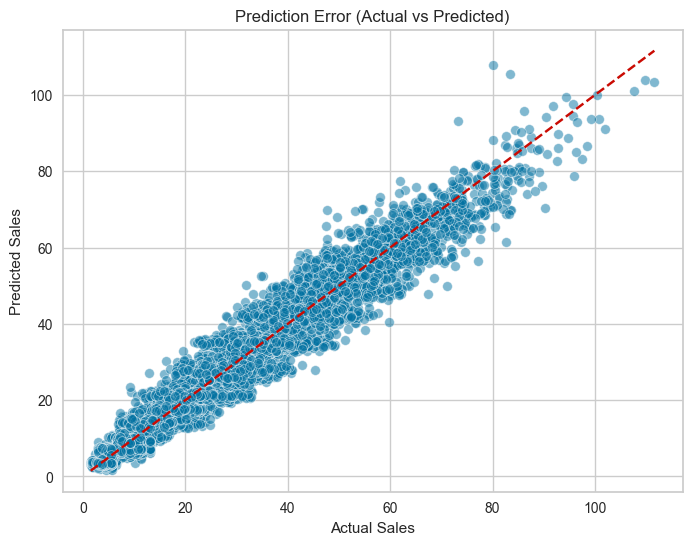

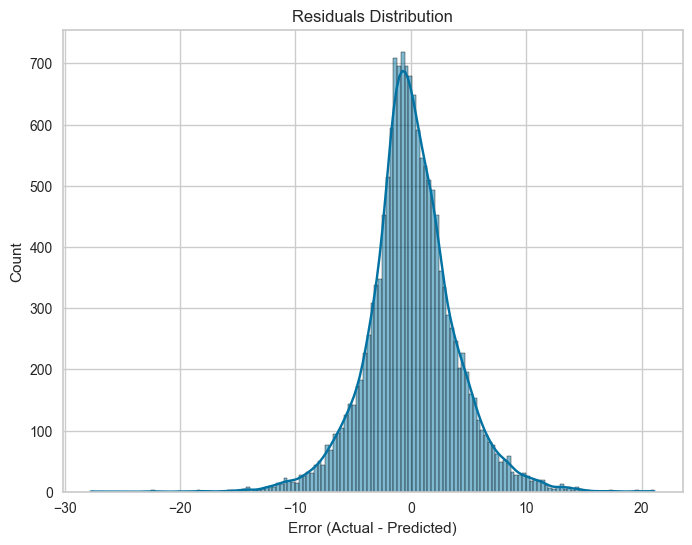

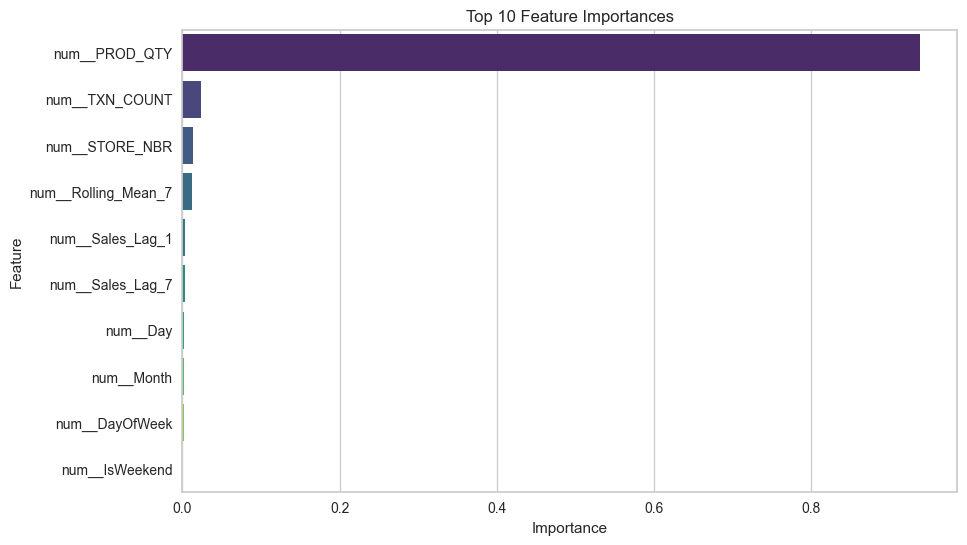

In [47]:
# 2.5 Evaluation & Insights
evaluate_model(best_reg_pipeline, X_test_reg, y_test_reg, task='regression')

In [48]:
# 2.6 Save Pipeline
save_pipeline_custom(best_reg_pipeline, 'sales_forecast_pipeline')

Pipeline saved successfully to: sales_forecast_pipeline.pkl


--- 
## Part 3: Customer Churn Prediction (Classification)

In [49]:
# 3.1 Feature Engineering
print("Generating Classification Features...")
max_date = df['DATE'].max()
cutoff_date = max_date - pd.DateOffset(months=3)
pre_cutoff_data = df[df['DATE'] <= cutoff_date]

customer_features = pre_cutoff_data.groupby('LYLTY_CARD_NBR').agg(
    Recency=('DATE', lambda x: (cutoff_date - x.max()).days),
    Frequency=('TXN_ID', 'count'),
    Monetary=('TOT_SALES', 'sum'),
    LIFESTAGE=('LIFESTAGE', 'first'),
    PREMIUM_CUSTOMER=('PREMIUM_CUSTOMER', 'first')
).reset_index()

active_post_cutoff = df[df['DATE'] > cutoff_date]['LYLTY_CARD_NBR'].unique()
customer_features['CHURN_FLAG'] = customer_features['LYLTY_CARD_NBR'].apply(
    lambda x: 0 if x in active_post_cutoff else 1
)
print(f"Classification Dataset Shape: {customer_features.shape}")

Generating Classification Features...
Classification Dataset Shape: (66732, 7)


In [50]:
# 3.2 Setup
X_train_clf, X_test_clf, y_train_clf, y_test_clf, prep_clf = setup_data(customer_features, 'CHURN_FLAG', task='classification')
print("Data Split Complete.")

Data Split Complete.


In [51]:
# 3.3 Compare Models (With SMOTE, No Cross-Validation)
# SMOTE is enabled for classification to handle class imbalance
best_base_clf, clf_name = compare_models(X_train_clf, y_train_clf, prep_clf, task='classification', use_smote=True)

Comparing Models for CLASSIFICATION (Validation Split)...
Best Model: XGBoost


,Model,Val Accuracy,Time (s)
2,XGBoost,0.686991,7.539740
0,Logistic Regression,0.662171,2.349667
1,Random Forest,0.643533,4.403798


In [52]:
# 3.4 Hyperparameter Tuning (With SMOTE)
best_clf_pipeline = tune_model(best_base_clf, clf_name, X_train_clf, y_train_clf, prep_clf, task='classification', use_smote=True)


--- Tuning XGBoost ---
Applying SMOTE inside Cross-Validation...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best Parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 6, 'classifier__n_estimators': 200}


--- Model Evaluation ---
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.69      0.70      7031
           1       0.67      0.70      0.68      6316

    accuracy                           0.69     13347
   macro avg       0.69      0.69      0.69     13347
weighted avg       0.69      0.69      0.69     13347

Accuracy: 0.6935
AUC-ROC:  0.6936


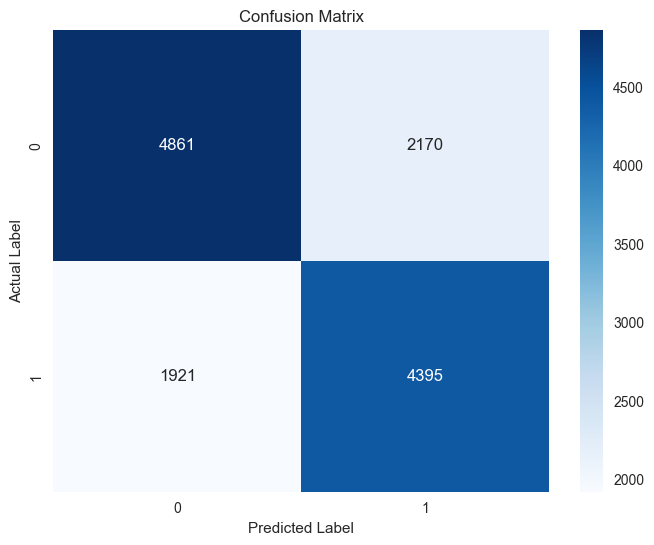

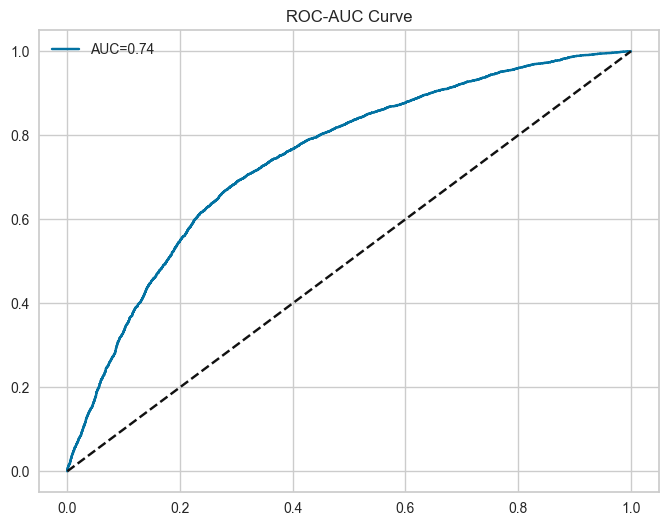

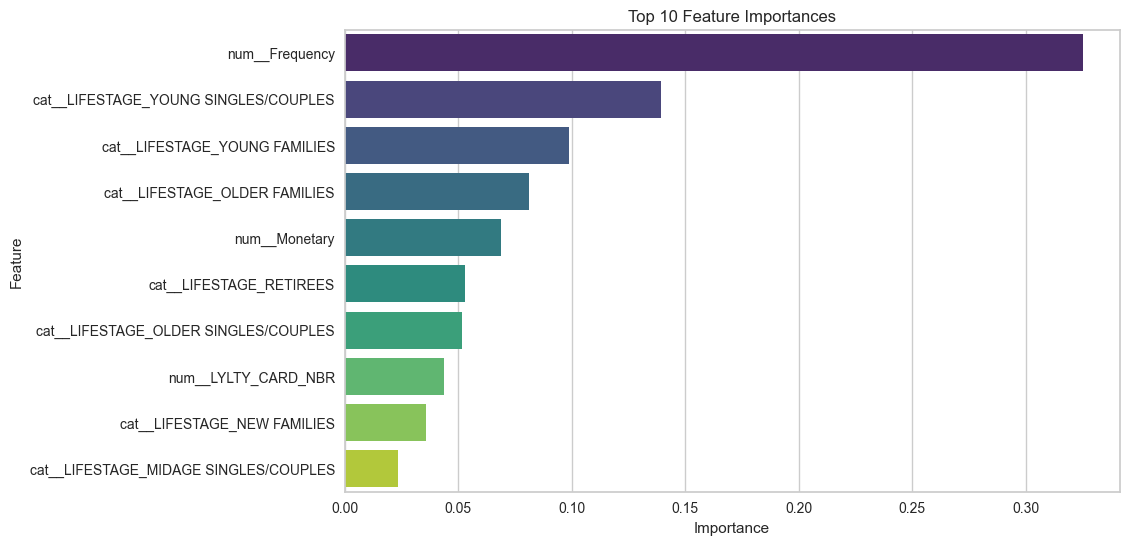

In [53]:
# 3.5 Evaluation & Insights
evaluate_model(best_clf_pipeline, X_test_clf, y_test_clf, task='classification')

In [54]:
# 3.6 Save Pipeline
save_pipeline_custom(best_clf_pipeline, 'churn_prediction_pipeline')

Pipeline saved successfully to: churn_prediction_pipeline.pkl
